# Chaotic Saddle Computations (Sprinkler Method)

This notebook starts by testing the new `return_mod_period` flag in `FastSitnikovSimulation.phi_fast` for `e=0.5`.

In [1]:
from pathlib import Path
import sys
import numpy as np

# Make project root importable from this experiment folder
ROOT = Path.cwd().parents[2]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.integrator.integrate import FastSitnikovSimulation

sim = FastSitnikovSimulation(e=0.5, solver_method='RK45')
sim

In [2]:
# Validate that raw time and modulo time are consistent
t0 = 20.0 * np.pi + 0.37
candidate_velocities = np.linspace(0.15, 1.2, 14)

hit = None
for v0 in candidate_velocities:
    v_mod, t_mod = sim.phi_fast(v0, t0, t_max=60.0, return_mod_period=True)
    v_raw, t_raw = sim.phi_fast(v0, t0, t_max=60.0, return_mod_period=False)
    if v_mod is not None and v_raw is not None:
        hit = (v0, v_mod, t_mod, v_raw, t_raw)
        break

if hit is None:
    raise RuntimeError('No returning orbit found in candidate velocity set; increase t_max or widen velocity scan.')

v0, v_mod, t_mod, v_raw, t_raw = hit
print(f'Using v0 = {v0:.6f}')
print(f'v_mod = {v_mod:.12f}, v_raw = {v_raw:.12f}')
print(f't_mod = {t_mod:.12f}, t_raw = {t_raw:.12f}')
print(f't_raw % (2pi) = {np.mod(t_raw, 2.0*np.pi):.12f}')

assert np.isclose(v_mod, v_raw, rtol=1e-10, atol=1e-12), 'Velocity mismatch between mod/raw modes'
assert np.isclose(t_mod, np.mod(t_raw, 2.0*np.pi), rtol=1e-10, atol=1e-12), 'Time modulo relation failed'
assert t_raw >= t0, 'Raw crossing time should be absolute and not wrapped'
print('Flag test passed.')

Using v0 = 0.150000
v_mod = 0.098174254053, v_raw = 0.098174254053
t_mod = 1.197396366497, t_raw = 64.029249438293
t_raw % (2pi) = 1.197396366497
Flag test passed.


## Step 1: Fixed Parameters and Deterministic Setup

We now implement the first sprinkler-method pilot with:
- `e = 0.5`
- `t0 = 0`
- `t_max = 20*pi`
- strict `>100` crossings checked via `max_crossings=101`
- deterministic RNG seed

In [3]:
from src.utils.boundary import B1_v_func

E = 0.5
T0 = 0.0
N0 = 1000
N_STEPS = 40
SEED = 20260406

rng = np.random.default_rng(SEED)

sim = FastSitnikovSimulation(e=E, solver_method='RK45')

print('Configured deterministic pilot:')
print(f'  E = {E}')
print(f'  T0 = {T0}')
print(f'  N0 = {N0}, N_STEPS = {N_STEPS}, seed = {SEED}')

Configured deterministic pilot:
  E = 0.5
  T0 = 0.0
  N0 = 1000, N_STEPS = 40, seed = 20260406


In [4]:
# Compute v_max from the boundary at t=0, then find v_min from the >100-crossings rule
# Use a moderate boundary sampling to keep this interactive while still using B1_v_func.
v_escape_t0 = float(B1_v_func(E, dv=2e-3, N_t=40)(0.0))
v_max = v_escape_t0 - 0.02

print(f'v_max from boundary at t=0: {v_max:.12f}')

v_max from boundary at t=0: 2.745213574142


In [7]:
N_min_test = 31
N_coarse_grid = 10
N_fine_grid = 10

k_offsets = 1e-2 * np.array([5, 4, 3, 2, 1, 0], dtype=float)

def qualifies_for_vmin(v_candidate):
    for off in k_offsets:
        v_test = v_candidate - off
        if v_test <= 0.0:
            return False
        n_cross = sim.fast_crossings_iterated(v_test, T0, max_crossings=N_min_test)
        if n_cross < N_min_test:
            return False
    return True

# Deterministic 2-stage scan for the highest qualifying v*
# User-informed bracket for faster search
v_scan_lo = 2.0
v_scan_hi = 2.5
if v_scan_hi <= v_scan_lo:
    raise RuntimeError(
        f'Invalid scan interval after boundary cap: [{v_scan_lo:.6f}, {v_scan_hi:.6f}]'
    )

coarse_grid = np.linspace(v_scan_lo, v_scan_hi, N_coarse_grid)
v_star_coarse = None
for vv in coarse_grid:
    if qualifies_for_vmin(vv):
        v_star_coarse = vv
    else:
        break

if v_star_coarse is None:
    raise RuntimeError('No qualifying v* found in coarse scan; expand search interval or adjust t_max.')

coarse_step = coarse_grid[1] - coarse_grid[0]
fine_lo = v_star_coarse - coarse_step
fine_hi = v_star_coarse + coarse_step
fine_grid = np.linspace(fine_lo, fine_hi, N_fine_grid)

v_star = None
for vv in fine_grid:
    if qualifies_for_vmin(vv):
        v_star = vv
    else:
        break


if v_star is None:
    raise RuntimeError('Fine scan failed near coarse optimum; this is unexpected.')

v_min = v_star

print(f'v_escape(t=0) = {v_escape_t0:.12f}')
print(f'v_max        = {v_max:.12f}')
print(f'v_min        = {v_min:.12f}')
print(f'interval ok? {v_min < v_max}')

if not (v_min < v_max):
    raise RuntimeError(
        f'Computed interval is empty: v_min={v_min:.6f} >= v_max={v_max:.6f}. '
        'Need to revisit margin definitions or search strategy.'
    )

v_escape(t=0) = 2.765213574142
v_max        = 2.745213574142
v_min        = 2.339506172840
interval ok? True


In [8]:
# Pilot sprinkler run on R = {(t=0, v): v in (v_min, v_max)}
# Survivors at n0 approximate points near the stable manifold in initial space,
# midpoint survivors approximate the saddle, and final survivors approximate unstable directions.

v0_samples = rng.uniform(v_min, v_max, size=N0)
mid_step = N_STEPS // 2

survivor_initial_v = []
survivor_mid_t = []
survivor_mid_v = []
survivor_final_t = []
survivor_final_v = []
escape_step = np.full(N0, N_STEPS + 1, dtype=int)

for i, v_init in enumerate(v0_samples):
    t_curr = T0
    v_curr = float(v_init)
    mid_state = None
    survived = True

    for step in range(1, N_STEPS + 1):
        v_next, t_next = sim.phi_fast(v_curr, t_curr, return_mod_period=True)
        if v_next is None:
            escape_step[i] = step
            survived = False
            break

        v_curr = float(v_next)
        t_curr = float(t_next)

        if step == mid_step:
            mid_state = (t_curr, v_curr)

    if survived:
        survivor_initial_v.append(float(v_init))
        if mid_state is None:
            raise RuntimeError('Missing midpoint state for a surviving trajectory.')
        survivor_mid_t.append(mid_state[0])
        survivor_mid_v.append(mid_state[1])
        survivor_final_t.append(t_curr)
        survivor_final_v.append(v_curr)

survivor_initial_v = np.array(survivor_initial_v)
survivor_mid_t = np.array(survivor_mid_t)
survivor_mid_v = np.array(survivor_mid_v)
survivor_final_t = np.array(survivor_final_t)
survivor_final_v = np.array(survivor_final_v)

print(f'Survivors after n0={N_STEPS}: {survivor_initial_v.size}/{N0}')
print(f'Estimated survival fraction: {survivor_initial_v.size / N0:.4f}')
print(f'Min/Max finite escape step: {escape_step.min()} / {escape_step[escape_step <= N_STEPS].max() if np.any(escape_step <= N_STEPS) else "none"}')

Survivors after n0=40: 23/1000
Estimated survival fraction: 0.0230
Min/Max finite escape step: 1 / 39


In [12]:
import importlib
import src.analysis.stable_islands as stable_islands

importlib.reload(stable_islands)

<module 'src.analysis.stable_islands' from 'C:\\Users\\Admin\\Desktop\\TFG\\CelestialMechanics\\sitnikov\\src\\analysis\\stable_islands.py'>

In [ ]:
from src.utils.boundary import B1_v_func

# Reference boundaries for visual comparison
theta_ref = np.linspace(0.0, 2.0 * np.pi, 361)
outer_boundary_func = B1_v_func(E, dv=2e-3, N_t=80)
v_outer_boundary = outer_boundary_func(theta_ref)

In [13]:
from src.analysis.stable_islands import outer_boundary_spline_from_interior_point

# Stable central-island boundary (approximate from one interior seed)
fit_island, _ = outer_boundary_spline_from_interior_point(
    e=E,
    p0=(0.25, 0.10),
    n_samples=80,
    positive_v_search=True,
    expected_dist=2.0,
    max_crossings=80,
    dist_error=1e-2,
    max_iterations=12,
    n_starts=8,
    max_passes=16,
    spline_degree=3,
    smoothing=1e-2,
    n_eval=400,
  )
island_orbit = fit_island['boundary_orbit']
theta_island = np.mod(island_orbit[:, 1], 2.0 * np.pi)
v_island = island_orbit[:, 0]
order_island = np.argsort(theta_island)
theta_island_plot = np.concatenate([theta_island[order_island], theta_island[order_island][:1] + 2.0 * np.pi])
v_island_plot = np.concatenate([v_island[order_island], v_island[order_island][:1]])

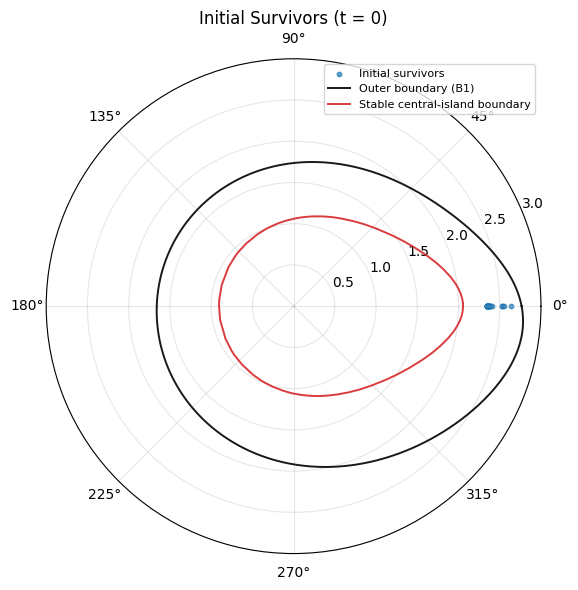

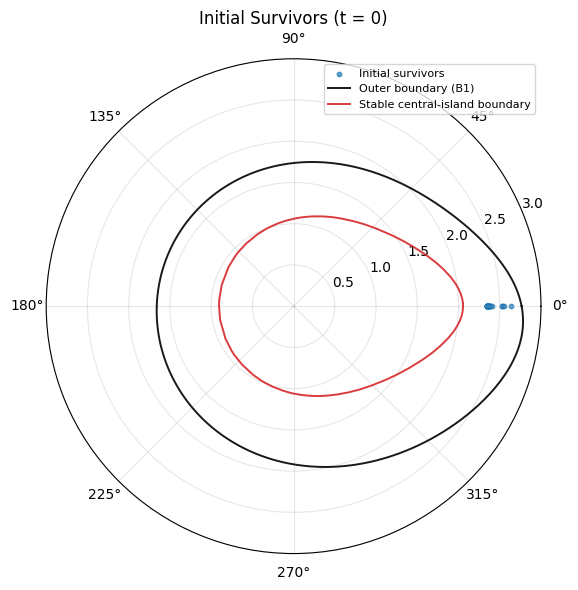

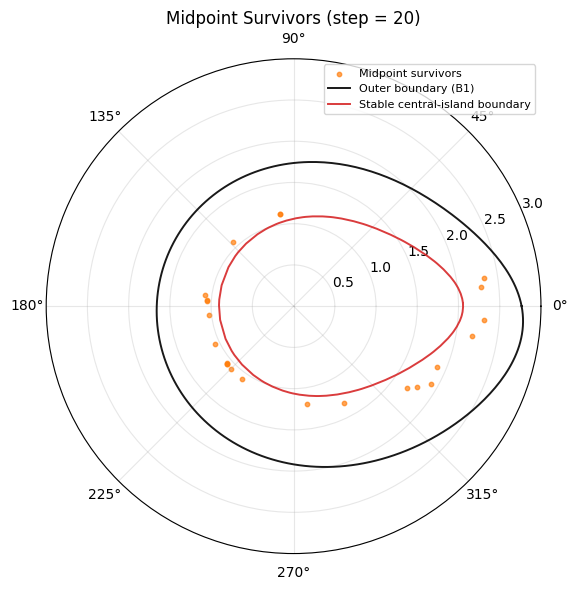

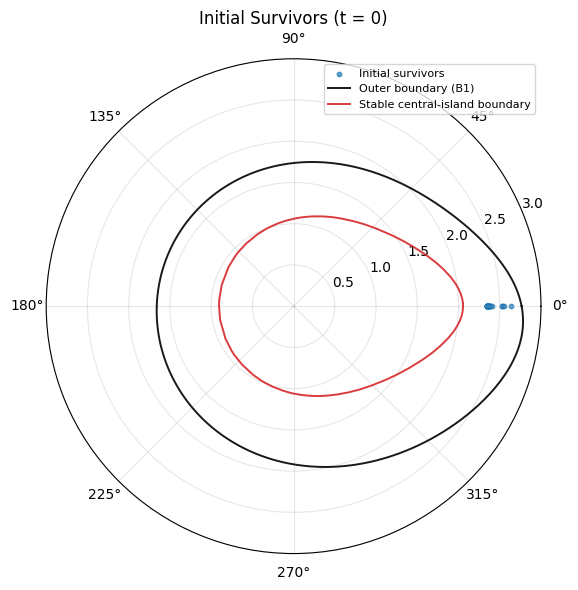

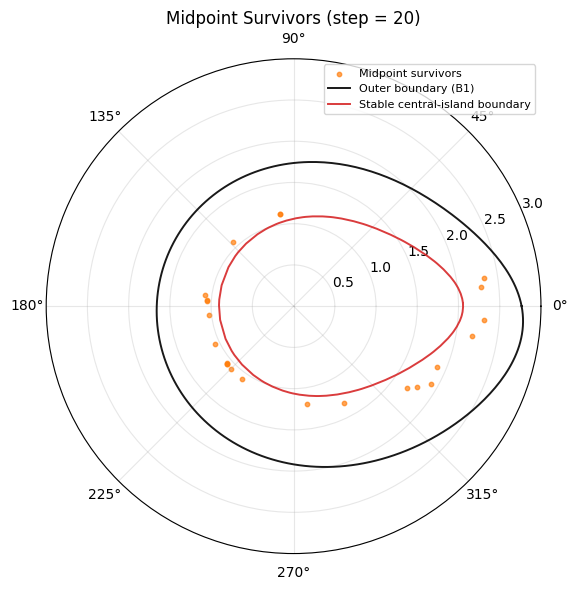

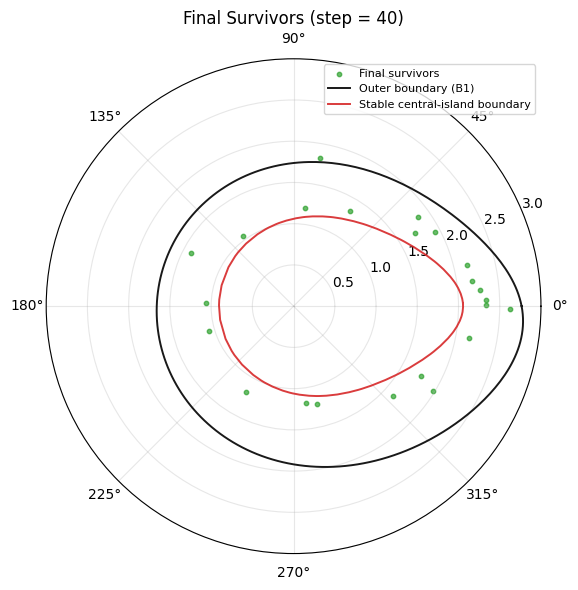

In [14]:
import matplotlib.pyplot as plt

from src.analysis.stable_islands import outer_boundary_spline_from_interior_point

if survivor_initial_v.size == 0:
    raise RuntimeError('No survivors found; cannot produce survivor polar plots.')

# plot_dir = Path('plots')
# plot_dir.mkdir(parents=True, exist_ok=True)

theta_initial = np.zeros_like(survivor_initial_v, dtype=float)
theta_mid = np.mod(survivor_mid_t, 2.0 * np.pi)
theta_final = np.mod(survivor_final_t, 2.0 * np.pi)


# Figure 1: initial survivors
fig1, ax1 = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax1.scatter(theta_initial, survivor_initial_v, s=10, alpha=0.7, color='tab:blue', label='Initial survivors')
ax1.plot(theta_ref, v_outer_boundary, color='black', linewidth=1.4, alpha=0.9, label='Outer boundary (B1)')
ax1.plot(theta_island_plot, v_island_plot, color='tab:red', linewidth=1.4, alpha=0.9, label='Stable central-island boundary')
ax1.set_title('Initial Survivors (t = 0)')
ax1.set_rlim(0.0, 3.0)
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(1)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=8)
fig1.tight_layout()
# fig1_path = plot_dir / 'survivors_initial_polar.png'
# fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: midpoint survivors
fig2, ax2 = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax2.scatter(theta_mid, survivor_mid_v, s=10, alpha=0.7, color='tab:orange', label='Midpoint survivors')
ax2.plot(theta_ref, v_outer_boundary, color='black', linewidth=1.4, alpha=0.9, label='Outer boundary (B1)')
ax2.plot(theta_island_plot, v_island_plot, color='tab:red', linewidth=1.4, alpha=0.9, label='Stable central-island boundary')
ax2.set_title(f'Midpoint Survivors (step = {mid_step})')
ax2.set_rlim(0.0, 3.0)
ax2.set_theta_zero_location('E')
ax2.set_theta_direction(1)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=8)
fig2.tight_layout()
# fig2_path = plot_dir / 'survivors_midpoint_polar.png'
# fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: final survivors
fig3, ax3 = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax3.scatter(theta_final, survivor_final_v, s=10, alpha=0.7, color='tab:green', label='Final survivors')
ax3.plot(theta_ref, v_outer_boundary, color='black', linewidth=1.4, alpha=0.9, label='Outer boundary (B1)')
ax3.plot(theta_island_plot, v_island_plot, color='tab:red', linewidth=1.4, alpha=0.9, label='Stable central-island boundary')
ax3.set_title(f'Final Survivors (step = {N_STEPS})')
ax3.set_rlim(0.0, 3.0)
ax3.set_theta_zero_location('E')
ax3.set_theta_direction(1)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper right', fontsize=8)
fig3.tight_layout()
# fig3_path = plot_dir / 'survivors_final_polar.png'
# fig3.savefig(fig3_path, dpi=300, bbox_inches='tight')
plt.show()

# print('Saved figures:')
# print(f'  {fig1_path.resolve()}')
# print(f'  {fig2_path.resolve()}')
# print(f'  {fig3_path.resolve()}')

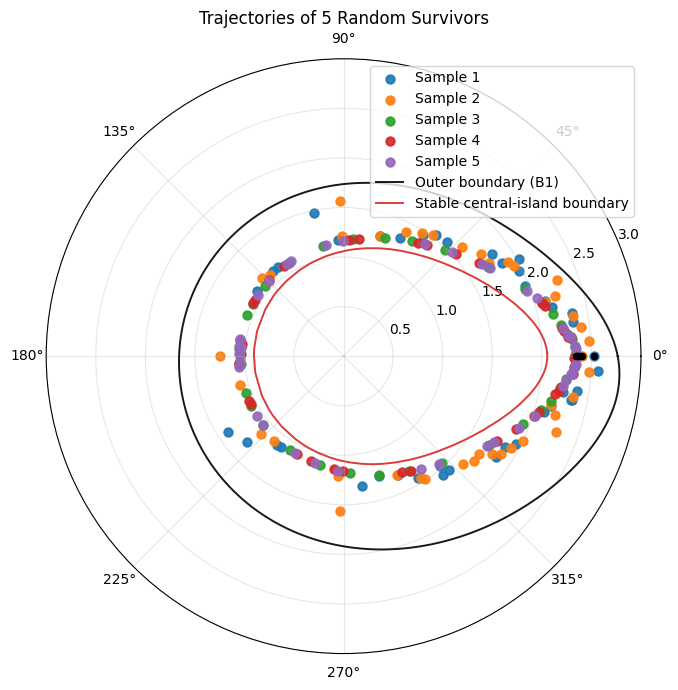

Picked survivor indices: [ 8  7 12  6  5]


In [18]:
n_plot = min(5, len(survivor_initial_v))
if n_plot == 0:
    raise ValueError('No survivors found, cannot plot trajectories.')

rng_plot = np.random.default_rng(SEED + 23)
picked_idx = rng_plot.choice(len(survivor_initial_v), size=n_plot, replace=False)

sim_traj = FastSitnikovSimulation(e=E)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})

for j, idx in enumerate(picked_idx, start=1):
    t_curr = float(theta_initial[idx])
    v_curr = float(survivor_initial_v[idx])

    theta_traj = np.zeros(N_STEPS + 1)
    v_traj = np.zeros(N_STEPS + 1)
    theta_traj[0] = t_curr
    v_traj[0] = v_curr

    for k in range(1, N_STEPS + 1):
        v_curr, t_curr = sim_traj.phi_fast(v=v_curr, t=t_curr)
        theta_traj[k] = t_curr
        v_traj[k] = v_curr

    ax.scatter(theta_traj, v_traj, linewidth=1.5, alpha=0.9, label=f'Sample {j}')
    ax.scatter(theta_traj[0], v_traj[0], s=20, color='black', zorder=3)


ax.plot(theta_ref, v_outer_boundary, color='black', linewidth=1.4, alpha=0.9, label='Outer boundary (B1)')
ax.plot(theta_island_plot, v_island_plot, color='tab:red', linewidth=1.4, alpha=0.9, label='Stable central-island boundary')

ax.set_title(f'Trajectories of {n_plot} Random Survivors')
ax.set_rlim(0.0, 3.0)
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

print('Picked survivor indices:', picked_idx)

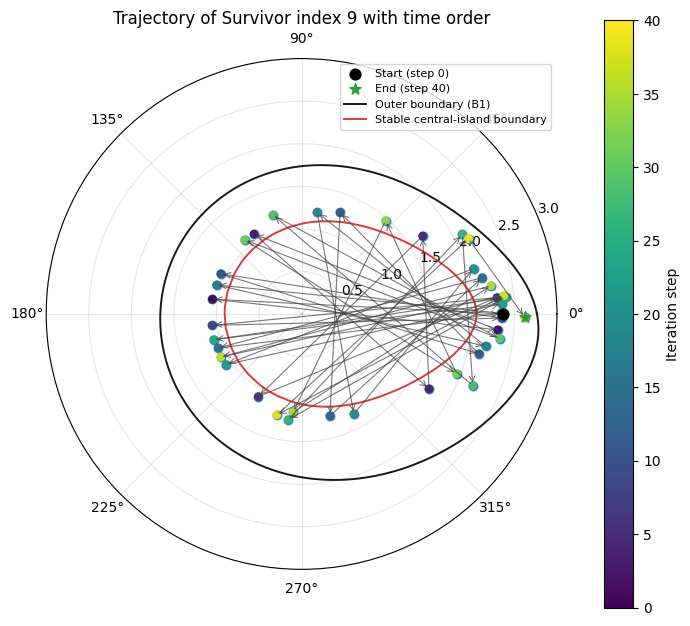

Plotted survivor index: 9
Start (theta, v): (0.000000, 2.366736)
End   (theta, v): (6.267774, 2.621028)


In [ ]:
idx_target = 9
if len(survivor_initial_v) == 0:
    raise ValueError('No survivors found, cannot plot trajectories.')
if idx_target < 0 or idx_target >= len(survivor_initial_v):
    raise IndexError(f'survivor index {idx_target} is out of range [0, {len(survivor_initial_v)-1}]')

sim_traj = FastSitnikovSimulation(e=E)

t_curr = float(theta_initial[idx_target])
v_curr = float(survivor_initial_v[idx_target])

a_plotted = 10
b_plotted = 30

if a_plotted < 0 or b_plotted < 0:
    raise ValueError('a_plotted and b_plotted must be non-negative.')
if a_plotted > b_plotted:
    raise ValueError('Expected a_plotted <= b_plotted.')
if b_plotted > N_STEPS:
    raise ValueError(f'b_plotted={b_plotted} exceeds N_STEPS={N_STEPS}.')

theta_traj = np.zeros(N_STEPS + 1)
v_traj = np.zeros(N_STEPS + 1)
theta_traj[0] = t_curr
v_traj[0] = v_curr

for k in range(1, N_STEPS + 1):
    v_curr, t_curr = sim_traj.phi_fast(v=v_curr, t=t_curr)
    theta_traj[k] = t_curr
    v_traj[k] = v_curr

# Restrict all plotted data to the requested iterate window [a_plotted, b_plotted]
plot_slice = slice(a_plotted, b_plotted + 1)
theta_plot = theta_traj[plot_slice]
v_plot = v_traj[plot_slice]
step_plot = np.arange(a_plotted, b_plotted + 1)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})

# Ordered path on the selected interval only
ax.plot(theta_plot, v_plot, color='tab:blue', linewidth=1.2, alpha=0.8, zorder=2)
sc = ax.scatter(theta_plot, v_plot, c=step_plot, cmap='viridis', s=28, zorder=3)

# Direction arrows for each transition within [a_plotted, b_plotted]
for k in range(a_plotted, b_plotted):
    i0 = k - a_plotted
    i1 = i0 + 1
    ax.annotate(
        '',
        xy=(theta_plot[i1], v_plot[i1]),
        xytext=(theta_plot[i0], v_plot[i0]),
        arrowprops=dict(arrowstyle='->', color='0.25', lw=0.8, alpha=0.7),
        zorder=4,
    )

# Mark interval endpoints explicitly
ax.scatter(theta_plot[0], v_plot[0], s=60, color='black', marker='o', zorder=5, label=f'Start (step {a_plotted})')
ax.scatter(theta_plot[-1], v_plot[-1], s=70, color='tab:green', marker='*', zorder=5, label=f'End (step {b_plotted})')

ax.plot(theta_ref, v_outer_boundary, color='black', linewidth=1.4, alpha=0.9, label='Outer boundary (B1)')
ax.plot(theta_island_plot, v_island_plot, color='tab:red', linewidth=1.4, alpha=0.9, label='Stable central-island boundary')

ax.set_title(f'Trajectory of survivor index {idx_target} (steps {a_plotted} to {b_plotted})')
ax.set_rlim(0.0, 3.0)
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=8)

cbar = plt.colorbar(sc, ax=ax, pad=0.08, fraction=0.05)
cbar.set_label('Iteration step')

fig.tight_layout()
plt.show()

print(f'Plotted survivor index: {idx_target}')
print(f'Plotted iterate window: [{a_plotted}, {b_plotted}]')
print(f'Window start (theta, v): ({theta_plot[0]:.6f}, {v_plot[0]:.6f})')
print(f'Window end   (theta, v): ({theta_plot[-1]:.6f}, {v_plot[-1]:.6f})')

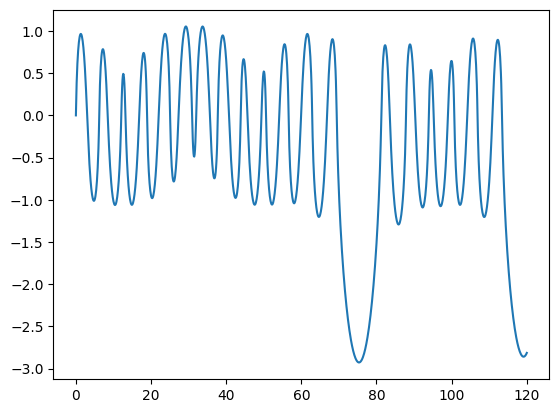

In [ ]:
idx_hardcoded = 21

v_start = survivor_initial_v[idx_hardcoded]
t_start = theta_initial[idx_hardcoded]

from src.utils.plotting import plot_position_sitnikov

plot_position_sitnikov(T = 120, dt = 0.1, e = E, v = v_start, t = t_start)